<a href="https://colab.research.google.com/github/yadalgic/manufacturing-anomaly-detection/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

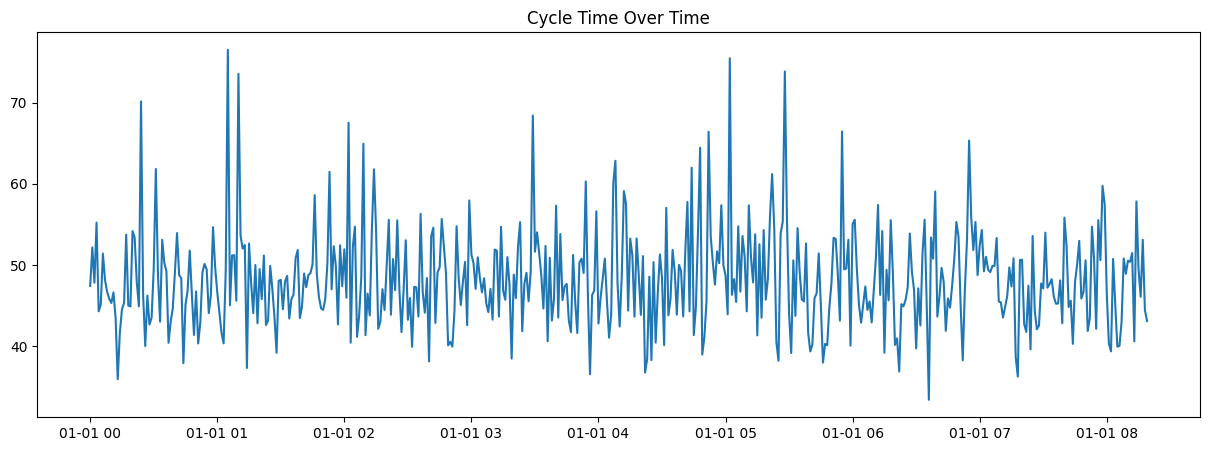

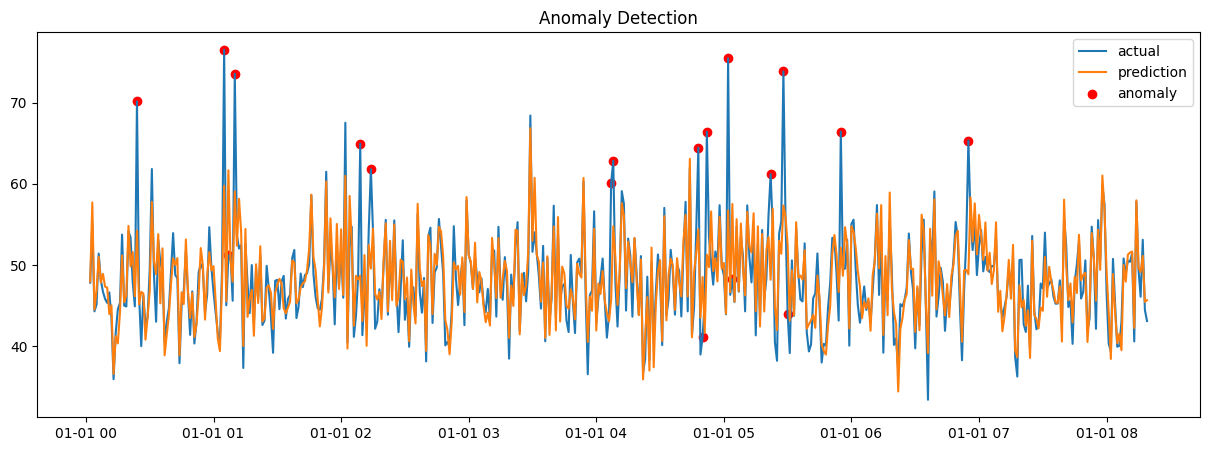


Feature Correlation with Cycle Time:
cycle_time        1.000000
prediction        0.832888
temperature       0.651495
rolling_mean_3    0.574528
anomaly           0.456515
residual          0.420155
shift             0.379440
lag_1             0.075451
pressure         -0.032582
Name: cycle_time, dtype: float64

Data saved as synthetic_manufacturing_data.csv


In [1]:
# ================================
# 1. IMPORT
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# ================================
# 2. DATA GENERATION (FAKE MES DATA)
# ================================
n = 500

time = pd.date_range(start="2024-01-01", periods=n, freq="min")

temperature = np.random.normal(30, 5, n)
pressure = np.random.normal(5, 1, n)
shift = np.random.choice([0, 1], n)  # 0=day, 1=night

cycle_time = 45 + np.random.normal(0, 2, n)

# realistic effects
cycle_time += (temperature - 30) * 0.8
cycle_time += shift * 5

# anomalies
anomaly_idx = np.random.choice(n, 15, replace=False)
cycle_time[anomaly_idx] += np.random.normal(20, 5, 15)

df = pd.DataFrame({
    "timestamp": time,
    "temperature": temperature,
    "pressure": pressure,
    "shift": shift,
    "cycle_time": cycle_time
})

# ================================
# 3. VISUALIZE RAW DATA
# ================================
plt.figure(figsize=(15,5))
plt.plot(df["timestamp"], df["cycle_time"])
plt.title("Cycle Time Over Time")
plt.show()

# ================================
# 4. FEATURE ENGINEERING
# ================================
df["lag_1"] = df["cycle_time"].shift(1)
df["rolling_mean_3"] = df["cycle_time"].rolling(3).mean()

df = df.dropna()

# ================================
# 5. MODEL (LINEAR REGRESSION)
# ================================
from sklearn.linear_model import LinearRegression

features = ["temperature", "pressure", "shift", "lag_1", "rolling_mean_3"]

X = df[features]
y = df["cycle_time"]

model = LinearRegression()
model.fit(X, y)

df["prediction"] = model.predict(X)

# ================================
# 6. ANOMALY DETECTION
# ================================
df["residual"] = abs(df["cycle_time"] - df["prediction"])

threshold = df["residual"].mean() + 2 * df["residual"].std()

df["anomaly"] = df["residual"] > threshold

# ================================
# 7. VISUALIZE ANOMALIES
# ================================
plt.figure(figsize=(15,5))

plt.plot(df["timestamp"], df["cycle_time"], label="actual")
plt.plot(df["timestamp"], df["prediction"], label="prediction")

anomalies = df[df["anomaly"]]
plt.scatter(anomalies["timestamp"], anomalies["cycle_time"], color="red", label="anomaly")

plt.legend()
plt.title("Anomaly Detection")
plt.show()

# ================================
# 8. ROOT CAUSE ANALYSIS
# ================================
correlation = df.corr(numeric_only=True)["cycle_time"].sort_values(ascending=False)

print("\nFeature Correlation with Cycle Time:")
print(correlation)

# ================================
# 9. SAVE DATA
# ================================
df.to_csv("synthetic_manufacturing_data.csv", index=False)

print("\nData saved as synthetic_manufacturing_data.csv")

# Manufacturing Cycle Time Anomaly Detection

## Problem
Detect abnormal increases in cycle time in manufacturing systems.

## Approach
- Synthetic data generation
- Feature engineering
- Regression model
- Residual-based anomaly detection

## Output
- Prediction vs Actual graph
- Detected anomalies